# Transition Matrices as a Directed Graph

This notebook shows on a tiny toy example how precomputed transition indices

`next_i` / `next_j` define a **directed graph in space and time**:

nodes are states $(k, i, j)$ and edges go from each state to its successor

at the next time step according to the transition matrices.


In [1]:
# 1. Define toy grid and dummy transition indices

import numpy as np



# Tiny grid: 3x3, single level, 3 time steps

Ni, Nj = 3, 3   # i = lat index, j = lon index

Nl = 1          # single vertical level

Nt = 3          # number of time steps with transitions k=0,1 -> k+1



# Allocate transition index arrays: shape (Nt, Nl, Ni, Nj)

next_i = np.zeros((Nt, Nl, Ni, Nj), dtype=int)

next_j = np.zeros((Nt, Nl, Ni, Nj), dtype=int)



# Simple rule: always try to step one cell east (j+1), but clamp at boundary.

# i stays the same, l stays the same.

for k in range(Nt):

    for l in range(Nl):

        for i in range(Ni):

            for j in range(Nj):

                i2 = i

                j2 = min(j + 1, Nj - 1)  # clamp at eastern boundary

                next_i[k, l, i, j] = i2

                next_j[k, l, i, j] = j2



print("next_i shape:", next_i.shape)

print("next_j shape:", next_j.shape)

print("Example transitions at k=0, level 0:")

for i in range(Ni):

    for j in range(Nj):

        print(f"(i={i}, j={j}) -> (i'={next_i[0,0,i,j]}, j'={next_j[0,0,i,j]})")

next_i shape: (3, 1, 3, 3)
next_j shape: (3, 1, 3, 3)
Example transitions at k=0, level 0:
(i=0, j=0) -> (i'=0, j'=1)
(i=0, j=1) -> (i'=0, j'=2)
(i=0, j=2) -> (i'=0, j'=2)
(i=1, j=0) -> (i'=1, j'=1)
(i=1, j=1) -> (i'=1, j'=2)
(i=1, j=2) -> (i'=1, j'=2)
(i=2, j=0) -> (i'=2, j'=1)
(i=2, j=1) -> (i'=2, j'=2)
(i=2, j=2) -> (i'=2, j'=2)


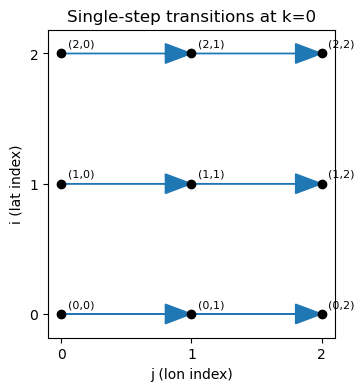

In [2]:
# 2. Visualize single-step transitions as arrows on a 2D grid

import matplotlib.pyplot as plt



k = 0  # time layer to visualize

l = 0  # level



fig, ax = plt.subplots(figsize=(4, 4))



# Plot grid points at (j, i)

for i in range(Ni):

    for j in range(Nj):

        ax.plot(j, i, "ko")

        ax.text(j + 0.05, i + 0.05, f"({i},{j})", fontsize=8)



# Draw arrows for transitions (i,j) -> (i', j')

for i in range(Ni):

    for j in range(Nj):

        i2 = next_i[k, l, i, j]

        j2 = next_j[k, l, i, j]

        if i2 == i and j2 == j:

            continue  # self-pointer; skip arrow here

        ax.arrow(

            j,

            i,

            j2 - j,

            i2 - i,

            head_width=0.15,

            head_length=0.2,

            fc="C0",

            ec="C0",

            length_includes_head=True,

        )



ax.set_aspect("equal", adjustable="box")

ax.set_xticks(range(Nj))

ax.set_yticks(range(Ni))

ax.set_xlabel("j (lon index)")

ax.set_ylabel("i (lat index)")

ax.set_title("Single-step transitions at k=0")

plt.show()

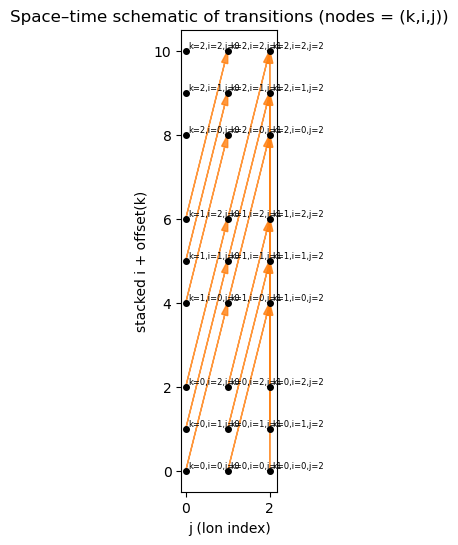

In [3]:
# 3. Space–time schematic: stack time levels



fig, ax = plt.subplots(figsize=(6, 6))



time_offset = Ni + 1  # vertical spacing between time layers



for k in range(Nt):

    for i in range(Ni):

        for j in range(Nj):

            y = i + k * time_offset

            ax.plot(j, y, "ko", markersize=4)

            ax.text(j + 0.05, y + 0.05, f"k={k},i={i},j={j}", fontsize=6)



# Draw edges forward in time

for k in range(Nt - 1):

    for i in range(Ni):

        for j in range(Nj):

            i2 = next_i[k, 0, i, j]

            j2 = next_j[k, 0, i, j]

            x0, y0 = j, i + k * time_offset

            x1, y1 = j2, i2 + (k + 1) * time_offset

            ax.arrow(

                x0,

                y0,

                x1 - x0,

                y1 - y0,

                head_width=0.15,

                head_length=0.3,

                fc="C1",

                ec="C1",

                length_includes_head=True,

                alpha=0.8,

            )



ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("j (lon index)")

ax.set_ylabel("stacked i + offset(k)")

ax.set_title("Space–time schematic of transitions (nodes = (k,i,j))")

plt.show()

In [4]:
# 4. Convert transition indices to an explicit graph structure (NetworkX)

import networkx as nx



# Directed graph where each node is a (k, i, j) tuple

G = nx.DiGraph()



for k in range(Nt):

    for i in range(Ni):

        for j in range(Nj):

            G.add_node((k, i, j))



for k in range(Nt - 1):

    for i in range(Ni):

        for j in range(Nj):

            i2 = next_i[k, 0, i, j]

            j2 = next_j[k, 0, i, j]

            G.add_edge((k, i, j), (k + 1, i2, j2), weight=1.0)



print("Number of nodes:", G.number_of_nodes())

print("Number of edges:", G.number_of_edges())

Number of nodes: 27
Number of edges: 18


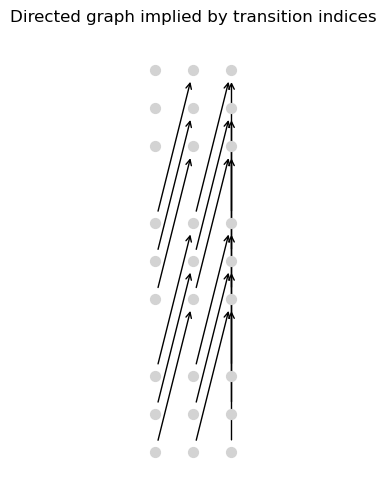

In [5]:
# 5. Visualize the graph with a layered layout by time



pos = {}

time_offset = Ni + 1



for k in range(Nt):

    for i in range(Ni):

        for j in range(Nj):

            # Same layout as in the space–time schematic

            pos[(k, i, j)] = (j, i + k * time_offset)



fig, ax = plt.subplots(figsize=(6, 6))



nx.draw_networkx_nodes(G, pos, node_size=50, node_color="lightgray", ax=ax)

nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=10, width=1.0, ax=ax)



ax.set_aspect("equal", adjustable="box")

ax.set_axis_off()

ax.set_title("Directed graph implied by transition indices")

plt.show()